# Baseline Model

Цель:
- подготовить данные для baseline-модели;
- корректно обработать проблемные признаки;
- разделить данные на train/test;
- обучить первую модель для задачи бинарной классификации churn;
- оценить качество модели на тестовой выборке.


In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

project_root = Path.cwd().resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.churn.data import load_dataset
from src.churn.preprocessing import prepare_modeling_dataframe

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## Data Loading

Загружаем исходный датасет через функцию из `src/churn/data.py`.

Это позволяет убрать повторяющийся код из ноутбука и сделать проект более модульным.


In [11]:
df = load_dataset()
df.shape


(7043, 21)

## Feature Preparation

Подготавливаем modeling-таблицу через функцию из `src/churn/preprocessing.py`.

На этом этапе:
- создается числовая версия `TotalCharges`;
- создается бинарная целевая переменная `Churn_binary`;
- исключается `customerID`;
- удаляются исходные текстовые колонки;
- удаляются строки с некорректными значениями `TotalCharges`.


In [12]:
df_model = prepare_modeling_dataframe(df)
df_model.shape


(7032, 20)

In [13]:
df_model.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_num,Churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
df_model.isna().sum().sort_values(ascending=False)


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges_num    0
Churn_binary        0
dtype: int64

In [16]:
df_model["Churn_binary"].value_counts(normalize=True)


Churn_binary
0    0.734215
1    0.265785
Name: proportion, dtype: float64

## Feature Matrix and Target

Разделяем данные на:
- `X` — признаки;
- `y` — целевая переменная.


In [17]:
X = df_model.drop(columns=["Churn_binary"])
y = df_model["Churn_binary"]

X.shape, y.shape


((7032, 19), (7032,))

## Train/Test Split

Разделяем данные на train и test.

Используем:
- `test_size=0.2` — 20% на тест;
- `random_state=42` — для воспроизводимости;
- `stratify=y` — чтобы сохранить баланс классов.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape


((5625, 19), (1407, 19))

## Feature Types

Определяем числовые и категориальные признаки, чтобы подготовить их разными способами внутри `Pipeline`.


In [19]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges_num'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## Preprocessing Pipeline

Используем единый preprocessing pipeline:
- для числовых признаков: median imputation, scaling;
- для категориальных признаков: most frequent imputation, one-hot encoding.

Такой подход делает подготовку данных воспроизводимой и уменьшает риск leakage.


In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges_num']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Logistic Regression Baseline

В качестве baseline используем `LogisticRegression`.


In [21]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

baseline_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges_num']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## Predictions

Получаем:
- классы (`predict`);
- вероятности положительного класса (`predict_proba`).

Вероятности нужны для метрик `ROC-AUC` и `PR-AUC`.


In [22]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]


## Evaluation

Оцениваем baseline-модель по метрикам, которые подходят для churn:
- `ROC-AUC`
- `PR-AUC`
- `Precision`
- `Recall`
- `F1`


In [23]:
metrics = {
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}

metrics


{'roc_auc': np.float64(0.8351344145860403),
 'pr_auc': np.float64(0.6183128860330439),
 'precision': np.float64(0.4901315789473684),
 'recall': np.float64(0.7967914438502673),
 'f1': np.float64(0.6069246435845214)}

## Classification Report

Дополнительно посмотрим на `classification_report`, чтобы увидеть качество модели по каждому классу отдельно.

Это помогает понять:
- насколько хорошо модель распознает churn и non-churn;
- как выглядят precision, recall и f1-score по классам;
- нет ли сильного перекоса в пользу одного из классов.


In [19]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### Interpretation

`classification_report` показывает, что baseline-модель заметно лучше распознает класс `0` (`no churn`) по `precision`, чем класс `1` (`churn`), однако для churn-класса достигается высокий `recall`.

Для класса `1` модель показывает:
- `precision = 0.49`
- `recall = 0.80`
- `f1-score = 0.61`

Это означает, что baseline находит большую часть клиентов с риском churn, но делает это ценой большого числа ложных срабатываний. Иными словами, модель скорее ориентирована на то, чтобы не пропустить churn-клиента, чем на точность положительных предсказаний.

Для churn-задачи это может быть приемлемым поведением на этапе baseline, особенно если бизнесу важнее охватить максимум клиентов с риском оттока. Однако при ограниченных ресурсах retention-команды такой уровень `precision` может быть недостаточным, поэтому следующим шагом имеет смысл проанализировать влияние порога классификации на баланс между `precision` и `recall`.


## Threshold Tuning

По умолчанию модель использует порог `0.5`, но для churn-задачи это не обязательно лучший вариант.

Посмотрим, как меняются `precision`, `recall` и `f1` при разных значениях threshold.


In [24]:
thresholds = np.arange(0.1, 0.91, 0.1)
thresholds


array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [26]:
threshold_metrics = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_metrics.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold),
            "recall": recall_score(y_test, y_pred_threshold),
            "f1": f1_score(y_test, y_pred_threshold),
        }
    )

threshold_df = pd.DataFrame(threshold_metrics)
threshold_df


,threshold,precision,recall,f1
0,0.1,0.344569,0.983957,0.510402
1,0.2,0.386437,0.959893,0.551036
2,0.3,0.414779,0.930481,0.573784
3,0.4,0.452150,0.871658,0.595434
4,0.5,0.490132,0.796791,0.606925
5,0.6,0.541414,0.716578,0.616801
6,0.7,0.611111,0.617647,0.614362
7,0.8,0.685446,0.390374,0.497445
8,0.9,0.782609,0.048128,0.090680


## Threshold vs Metrics

Построим график, чтобы визуально сравнить, как меняются `precision`, `recall` и `f1` при изменении порога классификации.


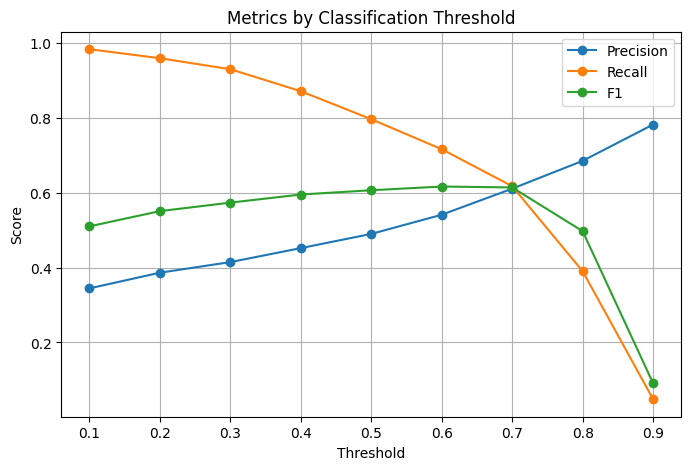

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

plt.title("Metrics by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()



## Threshold Tuning Summary

Анализ показал, что выбор порога классификации существенно влияет на баланс между `precision` и `recall`.

При низких threshold (`0.1–0.3`) модель достигает очень высокого `recall` (`0.93–0.98`), но `precision` остается низким (`0.34–0.41`). Это означает, что модель находит почти всех клиентов с риском churn, но делает много ложных срабатываний.

При повышении threshold `precision` постепенно растет, а `recall` снижается. В области `0.5–0.7` наблюдается наиболее разумный компромисс:
- при `0.5`: `precision = 0.49`, `recall = 0.80`, `f1 = 0.61`
- при `0.6`: `precision = 0.54`, `recall = 0.72`, `f1 = 0.62`
- при `0.7`: `precision = 0.61`, `recall = 0.62`, `f1 = 0.61`

Наибольшее значение `F1` достигается примерно при threshold `0.6`, что делает его хорошим кандидатом на более сбалансированный рабочий порог по сравнению со стандартным значением `0.5`.

Таким образом:
- если бизнесу важнее не пропускать churn-клиентов, можно использовать более низкий threshold;
- если нужен более сбалансированный компромисс между точностью и полнотой, разумным выбором выглядит threshold около `0.6`.


## Threshold Selection

По результатам предыдущего анализа в качестве более сбалансированного порога рассмотрим `threshold = 0.6`.

Этот порог выглядит разумным кандидатом, поскольку при нем достигается наилучшее значение `F1` среди протестированных вариантов, а `precision` становится выше по сравнению со стандартным `0.5`.


In [29]:
selected_threshold = 0.6
y_pred_06 = (y_proba >= selected_threshold).astype(int)


## Evaluation at Threshold = 0.6

Посчитаем основные метрики для выбранного порога и сравним их с baseline-результатом при `threshold = 0.5`.


In [37]:
metrics_06 = {
    "threshold": selected_threshold,
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
    "precision": precision_score(y_test, y_pred_06),
    "recall": recall_score(y_test, y_pred_06),
    "f1": f1_score(y_test, y_pred_06),
}

metrics_06


{'threshold': 0.6,
 'roc_auc': np.float64(0.8351344145860403),
 'pr_auc': np.float64(0.6183128860330439),
 'precision': np.float64(0.5414141414141415),
 'recall': np.float64(0.7165775401069518),
 'f1': np.float64(0.616800920598389)}

In [31]:
print(classification_report(y_test, y_pred_06))


              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [32]:
comparison_df = pd.DataFrame(
    [
        {
            "threshold": 0.5,
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
        },
        {
            "threshold": 0.6,
            "precision": precision_score(y_test, y_pred_06),
            "recall": recall_score(y_test, y_pred_06),
            "f1": f1_score(y_test, y_pred_06),
        },
    ]
)

comparison_df


,threshold,precision,recall,f1
0,0.5,0.490132,0.796791,0.606925
1,0.6,0.541414,0.716578,0.616801


## Final Threshold Decision

Сравнение показало, что переход от `threshold = 0.5` к `threshold = 0.6` улучшает баланс между `precision` и `recall`.

При `threshold = 0.6` модель показывает:
- `precision = 0.54`
- `recall = 0.72`
- `f1 = 0.62`

По сравнению со стандартным порогом `0.5`, `precision` вырос, а `f1` немного улучшился, при этом `recall` снизился, но остался на хорошем уровне. Это означает, что модель стала точнее в распознавании churn-клиентов и при этом по-прежнему сохраняет достаточно высокий охват.

Таким образом, `threshold = 0.6` можно рассматривать как более сбалансированный рабочий порог для baseline-модели. В то же время `threshold = 0.5` остается разумным вариантом, если бизнесу важнее максимизировать `recall` и находить как можно больше клиентов с риском оттока.


## Baseline Summary

В этом ноутбуке была построена первая baseline-модель для задачи бинарной классификации churn prediction на основе `LogisticRegression`.

Подготовка данных была выполнена с учетом результатов EDA:
- `customerID` исключен как идентификатор;
- `TotalCharges` приведен к числовому виду;
- строки с некорректными значениями `TotalCharges` были удалены;
- preprocessing реализован через `Pipeline` и `ColumnTransformer`.

Baseline-модель показала адекватное качество:
- `ROC-AUC = 0.835`
- `PR-AUC = 0.618`

При стандартном пороге `0.5` модель была ориентирована на высокий `recall`, но давала сравнительно много ложных срабатываний. После анализа зависимости метрик от порога был выбран `threshold = 0.6` как более сбалансированный вариант.

При `threshold = 0.6` модель показала:
- `precision = 0.54`
- `recall = 0.72`
- `f1 = 0.62`

Таким образом, baseline можно считать хорошей отправной точкой для дальнейшего улучшения модели. Следующие возможные шаги:
- сравнение с другой моделью;
- дополнительный feature engineering;
- дальнейшая настройка threshold под бизнес-сценарий.
